This code is designed to retrieve surface information from input A-D image files and given instrument response parameters

In [2]:
# Generic imports
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
import PIL
import copy
from scipy.interpolate import griddata
from scipy.special import gamma
import scipy.optimize as optimization
import os

# Reloading
from importlib import reload

# Local imports
import sys
sys.path.append('../../../')
import imagestuff as ims
import retrievestuff as rs; reload (rs)
import f90nml
import gradstuff as gds
import statstuff as sts

CUDA not available.


In [3]:
%matplotlib widget

In [4]:
# Specify the file we want to analyze (and output file name)
pwd = os.getcwd()
print(pwd)
startpos = pwd.find('crystals/')
case = pwd[startpos+9:]; print(case)
Segmentnamelistroot = 'Segments3'
imageroot = '2026-02-16'
Calibrationfile = 'Calibration.nml'

/Users/nesh/Documents/Repositories/ice2021/crystals/2026-02-16 (KD)/CASE1 (calibration)
2026-02-16 (KD)/CASE1 (calibration)


In [5]:
# Derivative names
Compressedfilename = Segmentnamelistroot+'_retrieved.npz'; print (Compressedfilename)
Roughnessfile = Segmentnamelistroot+'_roughness.jpg'; print(Roughnessfile)
Roughnessdatafile = Segmentnamelistroot+'_roughness.txt'; print(Roughnessdatafile)

Segments3_retrieved.npz
Segments3_roughness.jpg
Segments3_roughness.txt


In [6]:
# These are derivative names
Segmentnamelist = Segmentnamelistroot+'.nml'
Segmentfile = Segmentnamelist
SEMSegmentjpgfile =  Segmentnamelistroot+'.jpg'
Retrievedjpgfile =   Segmentnamelistroot+'_retrieved.jpg'
Compressedfilename = Segmentnamelistroot+'_retrieved'

In [7]:
# Read the input dataset, including spacing in micrometers
dx,dy,cA,cB,cC,cD,Filename = ims.getc2('', 'SEMimages/', imageroot,'A')
print("Filename, dx and dy", Filename, dx, dy)

SEMimages/2026-02-16-A.bmp
SEMimages/2026-02-16-B.bmp
SEMimages/2026-02-16-C.bmp
SEMimages/2026-02-16-D.bmp
Filename, dx and dy SEMimages/2026-02-16-A.bmp 1.2402339999999998 1.2402339999999998


In [8]:
# Extract the desired segments
Segments=f90nml.read(Segmentfile) #reads the file at a given path
nysegments=Segments['Segments']['nysegments']
nxsegments=Segments['Segments']['nxsegments']
nacross=Segments['Segments']['nacross']
ndown=Segments['Segments']['ndown']
nxstart=Segments['Segments']['nxstart']
ny1start=Segments['Segments']['ny1start']
ny2start = ny1start+ndown 
nx1list = []; nx2list = []
ny1list = []; ny2list = []
for ix in range(nxsegments):
    nx1start = nxstart+ix*nacross; nx2start = nxstart+(ix+1)*nacross 
    for i in range(nysegments):
        nx1list.append(nx1start); nx2list.append(nx2start)
        ny1list.append(ny1start+i*ndown); ny2list.append(ny2start+i*ndown)
nsegments = nxsegments*nysegments

Benchmark score for random signals = 7.657923022208859
Correlation of detectors A-D for each segment
for segment  0
nx= 41
ny= 41
0 1 6.916967895926357
0 2 -25.838668149299792
0 3 1.9362249926546777
1 2 1.6415190764354004
1 3 1.3369564018287003
2 3 10.102401677740856
Correlation score = 28.73622697540875

for segment  1
nx= 41
ny= 41
0 1 -0.035666558352015265
0 2 -15.123092303476762
0 3 1.601716912319774
1 2 3.834056532355478
1 3 3.511263307090007
2 3 6.80559204687862
Correlation score = 17.4533587771416



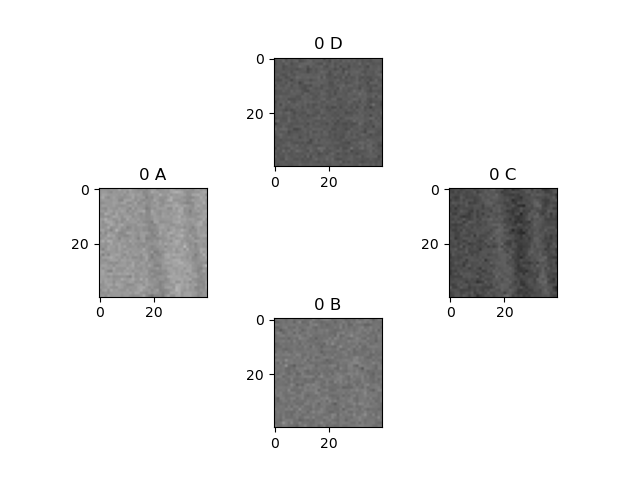

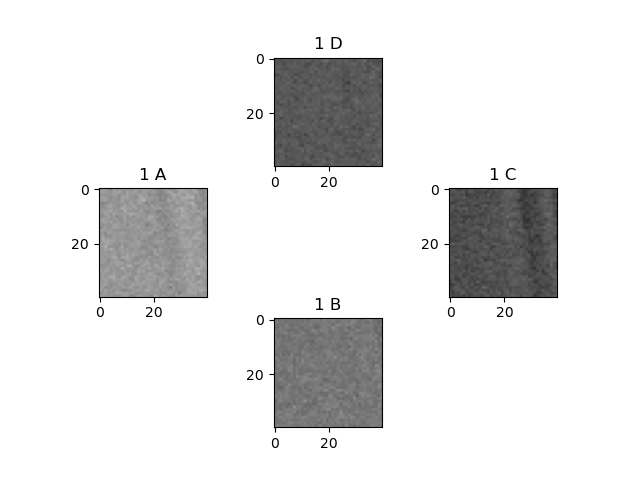

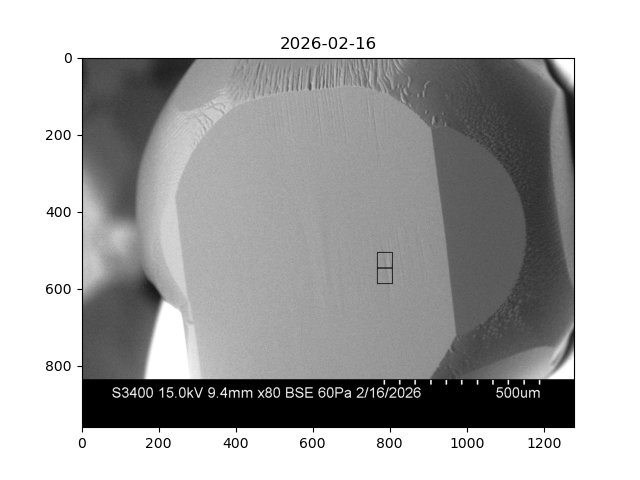

In [9]:
# Display
im = PIL.Image.open(Filename)

# Set up sub-grids in case of multiple segments
nyxgrid = []
for i in range(nsegments):
    nyxgridi = [ (y, x) for y in range(ny1list[i], ny2list[i]+1) for x in range(nx1list[i], nx2list[i]+1) ]
    nyxgrid.append(nyxgridi)

# Add the segments to the image
draw = PIL.ImageDraw.Draw(im)
for i in range(nsegments):
    nx1 = nx1list[i]
    nx2 = nx2list[i]
    ny1 = ny1list[i]
    ny2 = ny2list[i]
    ims.myrectangle(draw,(nx1,ny1),(nx2,ny2),5)

# What's the random expectation of information content
print('Benchmark score for random signals =', sts.randomcorrelation(nacross,ndown)*100*3)
    
# Loop to evaluate the information content in each segment
print('Correlation of detectors A-D for each segment')
for isegment in range(nsegments):
    
    print('for segment ', isegment)
    nx1=nx1list[isegment]; nx2=nx2list[isegment]; nx = nx2-nx1+1; print('nx=',nx)
    ny1=ny1list[isegment]; ny2=ny2list[isegment]; ny = ny2-ny1+1; print('ny=',ny)
    cAseg = cA[ny1:ny2,nx1:nx2]; #cAsegmean = np.mean(cAseg); print('<cA> =',cAsegmean)
    cBseg = cB[ny1:ny2,nx1:nx2]; #cBsegmean = np.mean(cBseg); print('<cB> =',cBsegmean)
    cCseg = cC[ny1:ny2,nx1:nx2]; #cCsegmean = np.mean(cCseg); print('<cC> =',cCsegmean)
    cDseg = cD[ny1:ny2,nx1:nx2]; #cDsegmean = np.mean(cDseg); print('<cD> =',cDsegmean)
    cseg = [cAseg,cBseg,cCseg,cDseg]
    infoscore = sts.getinfoscore(cseg)
    print('Correlation score =', infoscore)
    print('')

    # Show what the detectors see
    plt.figure()
    plt.subplot(334); plt.imshow(np.asarray(cAseg), cmap = 'Greys_r', vmin = 0, vmax = 255); plt.title(str(isegment)+' A')
    plt.subplot(338); plt.imshow(np.asarray(cBseg), cmap = 'Greys_r', vmin = 0, vmax = 255); plt.title(str(isegment)+' B')
    plt.subplot(336); plt.imshow(np.asarray(cCseg), cmap = 'Greys_r', vmin = 0, vmax = 255); plt.title(str(isegment)+' C')
    plt.subplot(332); plt.imshow(np.asarray(cDseg), cmap = 'Greys_r', vmin = 0, vmax = 255); plt.title(str(isegment)+' D')

# Show it
plt.figure()
plt.imshow(np.asarray(im), cmap = 'Greys_r', vmin = 0, vmax = 255)
plt.title(imageroot)

# Save a copy
im.save(SEMSegmentjpgfile)

In [10]:
# Read and unpack the calibration data

# Just echo input data files  
print(Calibrationfile)

# Extract
Calibration=f90nml.read(Calibrationfile) #reads the file at a given path
pA=Calibration['Calibration']['pA']
pB=Calibration['Calibration']['pB']
pC=Calibration['Calibration']['pC']
pD=Calibration['Calibration']['pD']

Calibration.nml


In [11]:
surfaces, sfuns, error= rs.retrieve_segments(\
    pA, pB, pC, pD, cA, cB, cC, cD, nx1list, nx2list, ny1list, ny2list, imageroot, dx=dx, dy=dy)

nsegments  2
Std deviation in input signal is 5.0
Std deviation in a priori is 15.0

Segment: 0 ( 1 of 2 )
for 766 507
Observed intensities (detector B):
mean, max, min = 96.67625 124.0 69.0
<diff>, std(diff), di2 = -6.892861856814066 57.55934619577421 118794.64312595227
<diff>, std(diff), di2 = -2.015857814246397 53.19985482570909 2708.687007407831

Segment: 1 ( 2 of 2 )
for 766 547
Observed intensities (detector B):
mean, max, min = 98.853125 124.0 78.0
<diff>, std(diff), di2 = -6.400518106814065 56.29090714384748 112161.97114319376
<diff>, std(diff), di2 = -1.804166838256288 52.05854989820244 2422.341651331474
Noverlap = 41
Angles between segments
0 1 0.2621039524507522  degrees
Working on optimizing the angles ...
40
80


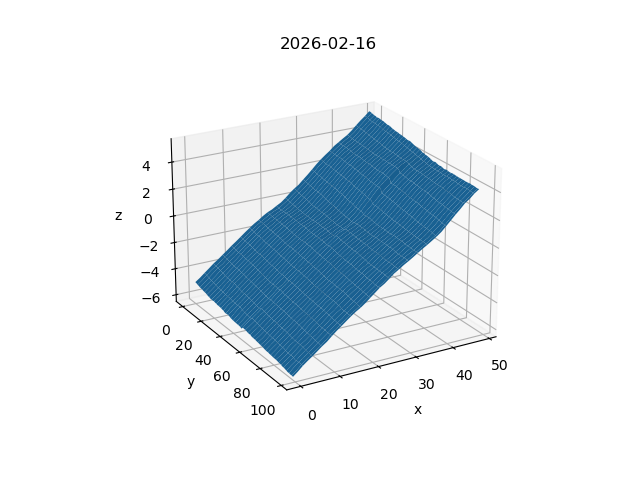

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(surfaces[0], surfaces[1], surfaces[2], rstride=2,cstride=2)
ax.invert_yaxis() # invert y axis (this fixes the right-hand-oriented vs left-hand-oriented system)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(imageroot)
ax.view_init(azim=-120,elev=22)

### Saving the solution
The compressed information below has a few items excised (I'm not sure why we need them)

In [14]:
#save an image
fig.savefig(Retrievedjpgfile)

print("saving", Compressedfilename)
np.savez_compressed(Compressedfilename, \
                    surfaceroot=imageroot, \
                    imageroot=imageroot, \
                    nx1list=nx1list, \
                    nx2list=nx2list, \
                    ny1list=ny1list, \
                    ny2list=ny2list, \
                    pA=pA, \
                    pB=pB, \
                    pC=pC, \
                    pD=pD, \
                    sA=sfuns[0], \
                    sB=sfuns[1], \
                    sC=sfuns[2], \
                    sD=sfuns[3], \
                    solution=surfaces[0])

saving Segments3_retrieved
